In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os

In [23]:
class Learningcurve:

    # Initialize the class with the file path to the CSV data
    def __init__(self, file_paths):
        # Accept either a single path (str) or a list of paths
        if isinstance(file_paths, str):
            file_paths = [file_paths]

        self.file_paths = file_paths
        self.dataframes = {}   # Dictionary to hold individual dataframes for each file
        self.df = None         # All .csv files combined into one dataframe
        self.load_data()

    # Load data
    def load_data(self):
        all_dfs = []

        for path in self.file_paths:
            df = pd.read_csv(path)
            df["session"] = df.groupby("Maze_ID").cumcount() + 1

            # Adds a column to the dataframe to identify the source file, (to distinguish between PID11_SESSION1, PID12_SESSION1, etc.) for each row
            label = os.path.splitext(os.path.basename(path))[0]
            df["source_file"] = label

            # Store the individual dataframe in the dictionary
            self.dataframes[label] = df
            all_dfs.append(df)

        # Combine all dataframes into one for combined plotting
        self.df = pd.concat(all_dfs, ignore_index=True) # Ignore index to make sure that all rows are indexed sequentially in the combined dataframe (e.g., 0, 1, 2, ...), instead of keeping the original indeces from the multiple unique .csv files
    
    # Code for plotting the sessions
    def plot(self, df, title, output_file=None, mazes=None):

        # Check if data is loaded
        if df is None or df.empty:
            print("No data available to plot.")
            return
        
        # Set up the plot structure
        plt.figure(figsize=(7, 5))

        # This makes unique Maze IDs, so that session numbers are plotted for each unique Maze_ID
        unique_mazes = sorted(df["Maze_ID"].unique())

        # If a list of mazes is provided, filter the data to only include those mazes
        if mazes is not None:
            unique_mazes = [maze for maze in unique_mazes if maze in mazes]

        # Plots time taken for each session for each unique Maze_ID
        for maze in unique_mazes:
            maze_data = df[df["Maze_ID"] == maze]

            plt.plot(
                maze_data["session"],   # X-axis: session number
                maze_data["time_taken"],# Y-axis: time taken
                label=f"Maze {maze}",   # Legend label
                marker="o",             # Adds dot
                markersize=10,          # Dot size
                linewidth=2,            # Line width
                alpha=0.8,              # Transparency of lines and dots
            )

        # Layout and labels
        plt.title(title, fontsize=14, pad=15)
        plt.xlabel("Session Number", fontsize=12)
        plt.ylabel("Time Taken (seconds)", fontsize=12)

        # Makes the X-axis only shows whole numbers
        plt.xticks(sorted(df["session"].unique()))

        # Adds grid lines, legend and tight layout for better spacing
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(title="Maze IDs", bbox_to_anchor=(1, 1), loc="upper left")
        plt.tight_layout()

        # Save or show the plot
        if output_file:
            plt.savefig(output_file, dpi=300, bbox_inches="tight")
            print(f"Plot saved successfully to {output_file}")
        else:
            plt.show()

        plt.close()

    # Plot each file individually, and makes the graphs saveable in a map
    def plot_each_file(self, output_dir=None, mazes=None):
        for label, df in self.dataframes.items():   # "label" (PID11_SESSION1, PID12_SESSION1, etc.) and "df" the corresponding dataframe
            output_file = None                      # Initialize output_file to None for each loop

            # If an output directory is specified, create it if it doesn't exist
            if output_dir:
                os.makedirs(output_dir, exist_ok=True)
                output_file = os.path.join(output_dir, f"{label}_sessions.png")

            # Call the plot function for each dataframe
            self.plot(
                df,
                title=f"Time Taken Across 5 Sessions by Maze ID: {label}",
                output_file=output_file,
                mazes=mazes
            )

    # Plot combined data from all files
    def plot_combined(self, output_file=None, mazes=None):

        # Check if combined data is available
        if self.df is None or self.df.empty:
            print("No data available to plot.")
            return

        # Set up the plot structure
        plt.figure(figsize=(7, 5))

        # This makes unique Maze IDs, so that session numbers are plotted for each unique Maze_ID
        unique_mazes = sorted(self.df["Maze_ID"].unique())

        # If a list of mazes is provided, filter the data to only include those mazes
        if mazes is not None:
            unique_mazes = [maze for maze in unique_mazes if maze in mazes]

        unique_files = sorted(self.df["source_file"].unique()) # This makes unique source files, so that session numbers are plotted for each unique source file (PID11_SESSION1, PID12_SESSION1, etc.)

        # Plots time taken for each session for each unique Maze_ID and source file
        line_styles = ["-", "--", "-.", ":"]  
        colors = ["tab:blue", "tab:orange", "tab:green"]

        # Loops through each unique Maze_ID and source file to plot the corresponding data
        for i, maze in enumerate(unique_mazes):
            
            # Gives each maze a unique color and keeps the colors consistent for maze_IDs
            color = colors[i % len(colors)]

            for j, source in enumerate(unique_files):

                # Filters the dataframe for the current maze and source file
                subset = self.df[
                    (self.df["Maze_ID"] == maze) & (self.df["source_file"] == source)
                ]
                if subset.empty:
                    continue
                
                # Plots the data for the current maze and source file with different line styles for each source file
                plt.plot(
                    subset["session"],   # X-axis: session number
                    subset["time_taken"],# Y-axis: time taken
                    label=f"{source} — Maze {maze}",   # Legend label
                    marker="o",             # Adds dot
                    markersize=10,          # Dot size
                    linewidth=2,            # Line width
                    alpha=0.8,              # Transparency of lines and dots
                    linestyle=line_styles[j % len(line_styles)], # Different line styles for different source files
                    color=color,
                )

        # Layout and labels
        plt.title("Time Taken Across Sessions — All Files Combined", fontsize=14, pad=15)
        plt.xlabel("Session Number", fontsize=12)
        plt.ylabel("Time Taken (seconds)", fontsize=12)

        # Makes the X-axis only shows whole numbers
        plt.xticks(sorted(self.df["session"].unique()))
        
        # Adds grid lines, legend and tight layout for better spacing
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(title="File — Maze ID", bbox_to_anchor=(1, 1), loc="upper left", fontsize=8)
        plt.tight_layout()

        # Save or show the plot
        if output_file:
            plt.savefig(output_file, dpi=300, bbox_inches="tight")
            print(f"Plot saved successfully to {output_file}")
        else:
            plt.show()

        plt.close()

    # Plot error bars for combined data from all files
    def plot_combined_with_error(self, output_file=None, error_type="std", mazes=None):

        # Check if combined data is available
        if self.df is None or self.df.empty:
            print("No data available to plot.")
            return

        # Set up the plot structure
        plt.figure(figsize=(7, 5))

        # This makes unique Maze_IDs, so that session numbers are plotted for each unique Maze_ID
        unique_mazes = sorted(self.df["Maze_ID"].unique())

        # If a list of mazes is provided, filter the data to only include those mazes
        if mazes is not None:
            unique_mazes = [maze for maze in unique_mazes if maze in mazes]

        # Plots mean time taken with error bars for each session for each unique Maze_ID
        for i, maze in enumerate(unique_mazes):
            maze_data = self.df[self.df["Maze_ID"] == maze]

            # Group by session and calculate mean and error (std or sem)
            grouped = maze_data.groupby("session")["time_taken"]
            mean_time = grouped.mean()
            if error_type == "std":
                error = grouped.std()
            elif error_type == "sem":
                error = grouped.sem()
            else:
                raise ValueError("error_type must be 'std' or 'sem'")

            plt.errorbar(
                mean_time.index,        # X-axis: session number
                mean_time.values,       # Y-axis: mean time taken
                yerr=error.values,      # Error bars
                label=f"Maze {maze}",   # Legend label
                marker="o",             # Adds dot
                markersize=10,          # Dot size
                linewidth=2,            # Line width
                alpha=0.8,              # Transparency of lines and dots
                capsize=5               # Size of the caps on the error bars
            )
            
            colors = ["tab:blue", "tab:orange", "tab:green"]  # Define a list of colors for the shaded regions

            # Create the shaded error region
            plt.fill_between(
                mean_time.index,                     # X-axis
                mean_time.values - error.values,     # Lower bound (Y - error)
                mean_time.values + error.values,     # Upper bound (Y + error)
                color=colors[i % len(colors)],                 # Matches the line color
                alpha=0.15,                          # Softer transparency for the background shading
                edgecolor="none"                     # Removes harsh borders
            )

        # Layout and labels
        plt.title(f"Mean Time Taken Across Sessions by Maze ID with {error_type.upper()} Error Bars", fontsize=14, pad=15)
        plt.xlabel("Session Number", fontsize=12)
        plt.ylabel("Time Taken (seconds)", fontsize=12)

        # Makes the X-axis only shows whole numbers
        plt.xticks(sorted(self.df["session"].unique()))

        # Adds grid lines, legend and tight layout for better spacing
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(title="Maze IDs", bbox_to_anchor=(1, 1), loc="upper left")
        plt.tight_layout()

        # Save or show the plot
        if output_file:
            plt.savefig(output_file, dpi=300, bbox_inches="tight")
            print(f"Plot saved successfully to {output_file}")
        else:
            plt.show()

        plt.close()

In [24]:
# TESTING
session = Learningcurve(["PID11_SESSION1.csv", "PID12_SESSION1.csv", "PID13_SESSION1.csv", "PID14_SESSION1.csv", "PID15_SESSION1.csv", "PID16_SESSION1.csv"])
session_learners = Learningcurve(["PID11_SESSION1.csv", "PID14_SESSION1.csv", "PID15_SESSION1.csv", "PID16_SESSION1.csv"])

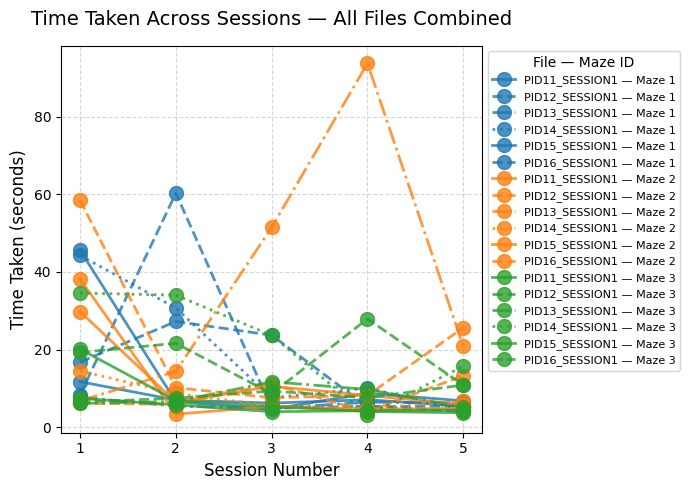

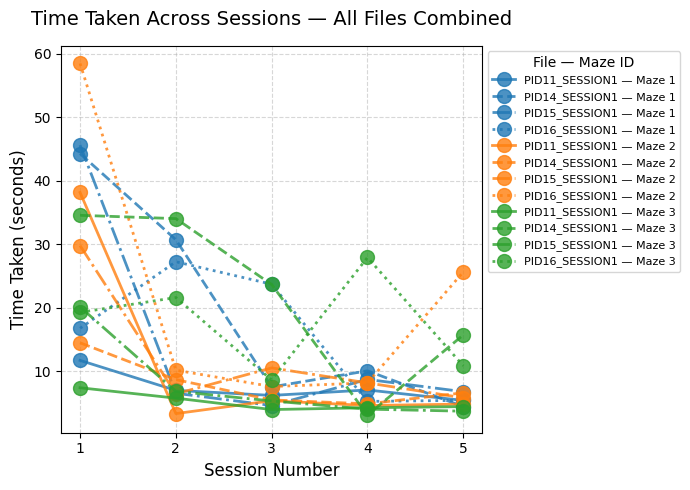

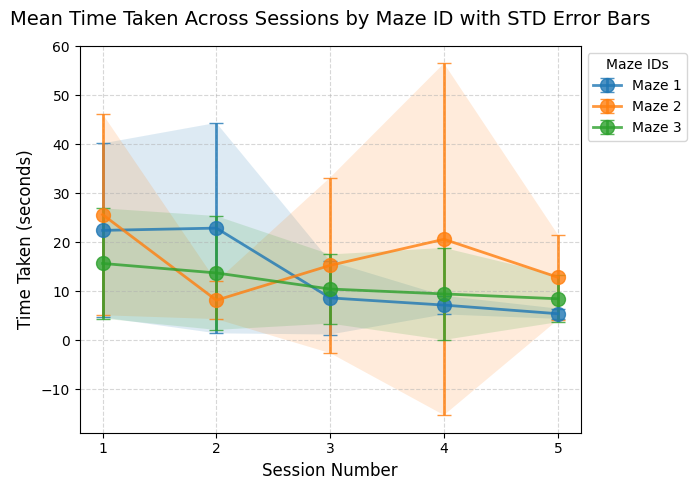

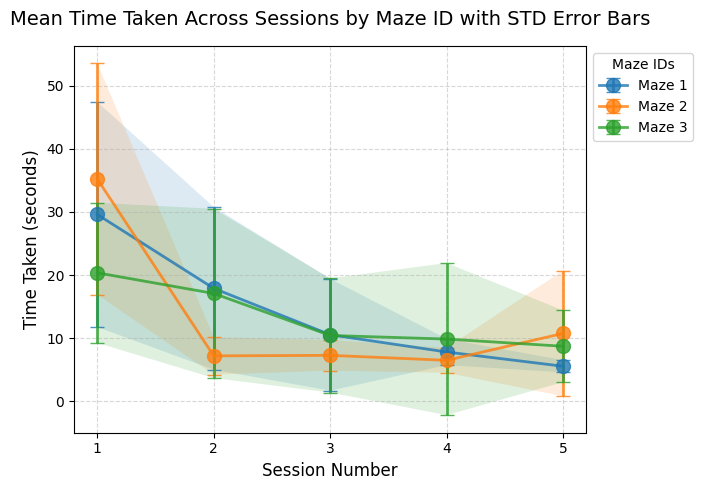

In [25]:
# One plot per file, saved into a folder
# session.plot_each_file(output_dir="per_file_plots")
# session.plot_combined(output_file="combined_plot.png")
session.plot_combined()
session_learners.plot_combined()
# One combined comparison plot: mean per Maze ID across files, with error bars
session.plot_combined_with_error(error_type="std")
session_learners.plot_combined_with_error(error_type="std")

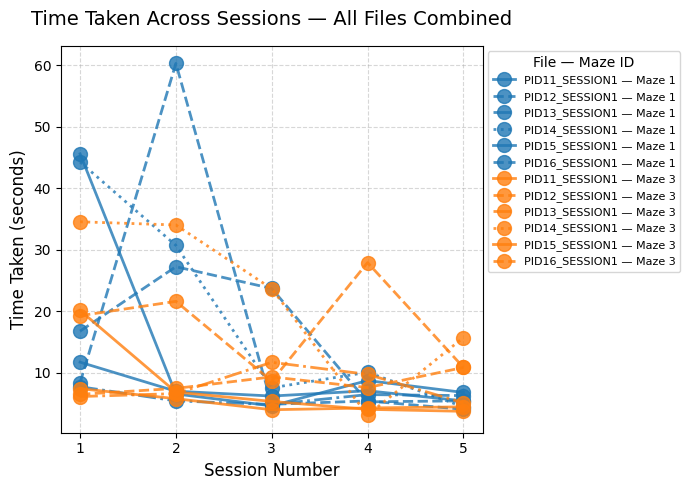

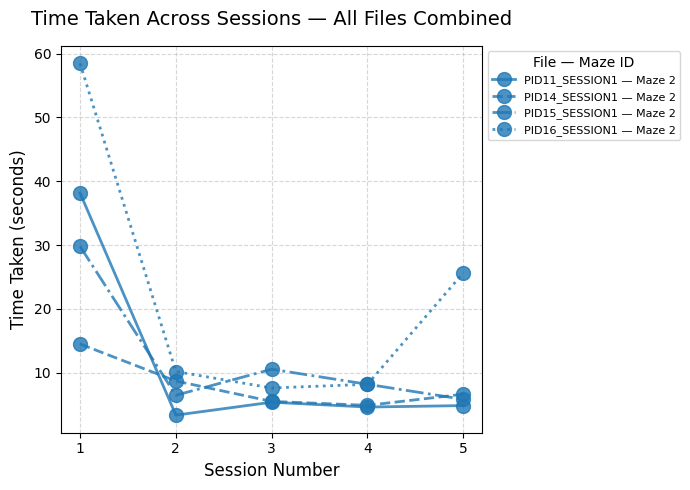

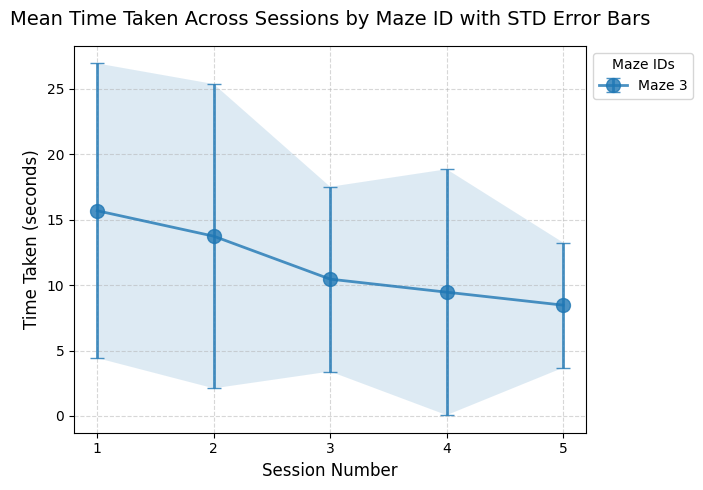

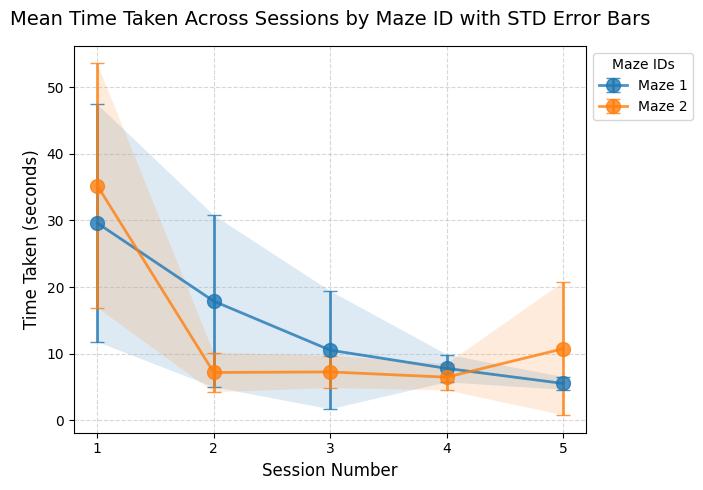

In [27]:
session.plot_combined(mazes=[1, 3])  # Example of filtering to specific mazes
session_learners.plot_combined(mazes=[2])
session.plot_combined_with_error(error_type="std", mazes=[3])
session_learners.plot_combined_with_error(error_type="std", mazes=[1, 2])